# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, make_scorer, r2_score, root_mean_squared_error

# Import train test split
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from pprint import pprint

# Import Decision Tree Regressor and Classifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

# Import Random Forest Regressor and Classifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

# Import time
import time

# Import Randomized Search CV
from sklearn.model_selection import RandomizedSearchCV

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Import kfold
from sklearn.model_selection import KFold

# Import cross val score
from sklearn.model_selection import cross_val_score

# Import math
import math

# Import log2
from math import log2

# Import classification report
from sklearn.metrics import classification_report

# Import SMOTE
from imblearn.over_sampling import SMOTE

np.random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/'
convabuse_filename = 'convabuse_imbalanced.csv'
dghs_filename = 'dynamically_generated_hate_speech_dataset_imbalanced.csv'
oaa_filename = 'online_abusive_attacks_class_imbalanced.csv'
us2020hs_filename = 'us_elections_2020_hate_speech_imbalanced.csv'
mlma_hate_speech_filename = 'MLMA_hate_speech_imbalanced.csv'

In [3]:
oaa_ridge_forward_features = ['Parent tweets',
 'Replies to parents',
 'Parent tweets with replies',
 'Toxic parent tweets',
 'Toxic replies',
 'Toxic replies to non-toxic parents',
 'Toxic replies to toxic parents',
 'Friends_count',
 'Listed_count',
 'Verified',
 'Statuses_count',
 'Retweet_count avg',
 'Retweet_count max',
 'Favorite_count min',
 'Repliers with min 1 toxic reply',
 'High toxicity parents',
 'High identity_attack parents',
 'High insult parents',
 'High profanity parents',
 'High threat parents',
 'High toxicity replies',
 'High identity_attack replies',
 'High insult replies',
 'High profanity replies',
 'High threat replies',
 '<3 replies parents',
 '>=3 replies parents',
 'Love',
 'Feminist',
 'Toxicity']

In [4]:
# Import the datasets
convabuse = pd.read_csv(f'{path}{convabuse_filename}')
dynamically_generated_hate_speech = pd.read_csv(f'{path}{dghs_filename}')
online_abusive_attacks = pd.read_csv(f'{path}{oaa_filename}')
us_elections_2020_hate_speech = pd.read_csv(f'{path}{us2020hs_filename}')
mlma_hate_speech = pd.read_csv(f'{path}{mlma_hate_speech_filename}')
mlma_hate_speech_sample = mlma_hate_speech.sample(frac=0.3, random_state=42)

In [5]:
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,7,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,1,0
2,7,0,0,0,0,0,0,0,0
3,7,1,0,0,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0


In [6]:
convabuse_X = convabuse.drop(columns=["abuse_level", "explicit", "target_groups", "implicit", "generalised", "individual"], axis=1)
convabuse_y = convabuse["abuse_level"]

In [7]:
dynamically_generated_hate_speech.head()

,label,type,annotator,target_groups,original
0,1.0,0,3,0,1
1,1.0,0,3,0,1
2,1.0,0,18,0,1
3,1.0,0,16,0,1
4,1.0,0,7,0,1


In [8]:
dghs_X = dynamically_generated_hate_speech.drop(columns=["label", "target_groups"], axis=1)
dghs_y = dynamically_generated_hate_speech["label"]

In [9]:
online_abusive_attacks.head()

,Toxic parent tweets,Toxic replies,Toxic Level
0,0.0,0.0,0
1,67.0,13.0,2
2,28.0,45.0,2
3,47.0,49.0,2
4,97.0,7.0,3


In [10]:
oaa_X = online_abusive_attacks.drop(columns=["Toxic Level"])
oaa_y = online_abusive_attacks["Toxic Level"]

In [11]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,1,0,1,0
1,1,0,1,0
2,-1,0,1,0
3,0,0,1,0
4,0,1,1,0


In [12]:
us2020hs_X = us_elections_2020_hate_speech.drop(columns=["HOF", "West"], axis=1)
us2020hs_y = us_elections_2020_hate_speech["HOF"]

In [13]:
mlma_hate_speech.head()

,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1,0,1,2,2
1,1,0,0,6,1
2,1,0,0,0,1
3,0,1,1,0,1
4,1,0,1,0,1


In [14]:
mlma_hate_speech_X = mlma_hate_speech.drop("target_groups", axis=1)
mlma_hate_speech_y = mlma_hate_speech["target_groups"]
mlma_hate_speech_X_sample = mlma_hate_speech_sample.drop("target_groups", axis=1)
mlma_hate_speech_y_sample = mlma_hate_speech_sample["target_groups"]

In [15]:
from sklearn.utils import class_weight

# Calculate class weights for each dataset
convabuse_class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(convabuse_y), y=convabuse_y)
dghs_class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(dghs_y), y=dghs_y)
oaa_class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(oaa_y), y=oaa_y)
us2020hs_class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(us2020hs_y), y=us2020hs_y)
mlma_hate_speech_class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(mlma_hate_speech_y), y=mlma_hate_speech_y)

# Convert class weights to a dictionary for use in Logistic Regression
convabuse_class_weight_dict = dict(zip(np.unique(convabuse_y), convabuse_class_weights))
dghs_class_weight_dict = dict(zip(np.unique(dghs_y), dghs_class_weights))
oaa_class_weight_dict = dict(zip(np.unique(oaa_y), oaa_class_weights))
us2020hs_class_weight_dict = dict(zip(np.unique(us2020hs_y), us2020hs_class_weights))
mlma_hate_speech_class_weight_dict = dict(zip(np.unique(mlma_hate_speech_y), mlma_hate_speech_class_weights))

In [16]:
# Implement KFold
convabuse_kf = KFold(n_splits=5, shuffle=True, random_state=42)
dghs_kf = KFold(n_splits=5, shuffle=True, random_state=42)
online_abusive_attacks_kf = KFold(n_splits=5, shuffle=True, random_state=42)
us2020hs_kf = KFold(n_splits=5, shuffle=True, random_state=42)
mlma_hate_speech_kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Modeling

In [17]:
# Get only the numeric features for each dataset
convabuse_X_numeric = convabuse_X.select_dtypes(include=np.number)
dghs_X_numeric = dghs_X.select_dtypes(include=np.number)
oaa_X_numeric = oaa_X.select_dtypes(include=np.number)
us2020hs_X_numeric = us2020hs_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric = mlma_hate_speech_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric_sample = mlma_hate_speech_X_sample.select_dtypes(include=np.number)

In [18]:
# Use standard scaler on the Convabuse X data
convabuse_scaler = StandardScaler()
convabuse_X_scaled = convabuse_scaler.fit_transform(convabuse_X_numeric)
convabuse_X_scaled = pd.DataFrame(convabuse_X_scaled, columns=convabuse_X_numeric.columns)

In [19]:
# Use standard scaler on the Dynamically Generated Hate Speech X data
dghs_scaler = StandardScaler()
dghs_X_scaled = dghs_scaler.fit_transform(dghs_X_numeric)
dghs_X_scaled = pd.DataFrame(dghs_X_scaled, columns=dghs_X_numeric.columns)

In [20]:
# Use standard scaler on the Online Abusive Attacks X data
oaa_scaler = StandardScaler()
oaa_X_scaled = oaa_scaler.fit_transform(oaa_X_numeric)
oaa_X_scaled = pd.DataFrame(oaa_X_scaled, columns=oaa_X_numeric.columns)

In [21]:
# Use standard scaler on the US elections 2020 hate speech X data
us2020hs_scaler = StandardScaler()
us2020hs_X_scaled = us2020hs_scaler.fit_transform(us2020hs_X_numeric)
us2020hs_X_scaled = pd.DataFrame(us2020hs_X_scaled, columns=us2020hs_X_numeric.columns)

In [22]:
# Use standard scaler on the MLMA hate speech X data
mlma_hate_speech_scaler = StandardScaler()
mlma_hate_speech_X_scaled = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_numeric)
mlma_hate_speech_X_scaled = pd.DataFrame(mlma_hate_speech_X_scaled, columns=mlma_hate_speech_X_numeric.columns)

In [23]:
# Use standard scaler on the MLMA hate speech X sample data
mlma_hate_speech_sample_scaler = StandardScaler()
mlma_hate_speech_X_sample_scaled = mlma_hate_speech_sample_scaler.fit_transform(mlma_hate_speech_X_numeric_sample)
mlma_hate_speech_X_sample_scaled = pd.DataFrame(mlma_hate_speech_X_sample_scaled, columns=mlma_hate_speech_X_numeric_sample.columns)

In [24]:
# Implement SMOTE to each dataset
smote = SMOTE(random_state=42)

convabuse_X_resampled, convabuse_y_resampled = smote.fit_resample(convabuse_X_scaled, convabuse_y)
dghs_X_resampled, dghs_y_resampled = smote.fit_resample(dghs_X_scaled, dghs_y)
oaa_X_resampled, oaa_y_resampled = smote.fit_resample(oaa_X_scaled, oaa_y)
us2020hs_X_resampled, us2020hs_y_resampled = smote.fit_resample(us2020hs_X_scaled, us2020hs_y)
mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled = smote.fit_resample(mlma_hate_speech_X_scaled, mlma_hate_speech_y)
mlma_hate_speech_X_sample_resampled, mlma_hate_speech_y_sample = smote.fit_resample(mlma_hate_speech_X_sample_scaled, mlma_hate_speech_y_sample)

In [25]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_resampled, convabuse_y_resampled, test_size=0.2, random_state=42, stratify=convabuse_y_resampled)
dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test = train_test_split(dghs_X_resampled, dghs_y_resampled, test_size=0.2, random_state=42, stratify=dghs_y_resampled)
oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test = train_test_split(oaa_X_resampled, oaa_y_resampled, test_size=0.2, random_state=42, stratify=oaa_y_resampled)
us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test = train_test_split(us2020hs_X_resampled, us2020hs_y_resampled, test_size=0.2, random_state=42, stratify=us2020hs_y_resampled)
mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y_resampled)
mlma_hate_speech_X_train_sample, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_train_sample, mlma_hate_speech_y_test_sample = train_test_split(mlma_hate_speech_X_sample_resampled, mlma_hate_speech_y_sample, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y_sample)

In [26]:
for columns in [convabuse_X_numeric.columns, dghs_X_numeric.columns, oaa_X_numeric.columns, us2020hs_X_numeric.columns, mlma_hate_speech_X_numeric.columns]:
  print(columns)

Index(['annotator_id', 'bot', 'system'], dtype='object')
Index(['type', 'annotator', 'original'], dtype='object')
Index(['Toxic parent tweets', 'Toxic replies'], dtype='object')
Index(['Trump', 'Biden'], dtype='object')
Index(['implicit', 'explicit', 'annotator_sentiment', 'abuse_level'], dtype='object')


In [27]:
# Get the length of each dataset
convabuse_length = len(convabuse_X_train)
dghs_length = len(dghs_X_train)
oaa_length = len(oaa_X_train)
us2020hs_length = len(us2020hs_X_train)
mlma_hate_speech_length = len(mlma_hate_speech_X_train)
mlma_hate_speech_sample_length = len(mlma_hate_speech_X_train_sample)

In [28]:
convabuse_log2 = math.ceil(log2(convabuse_length))
convabuse_1_percent = math.ceil(convabuse_length * 0.01)
convabuse_length, convabuse_log2, convabuse_1_percent

(40252, 16, 403)

In [29]:
dghs_log2 = math.ceil(log2(dghs_length))
dghs_1_percent = math.ceil(dghs_length * 0.01)
dghs_length, dghs_log2, dghs_1_percent

(35148, 16, 352)

In [30]:
oaa_log2 = math.ceil(log2(oaa_length))
oaa_1_percent = math.ceil(oaa_length * 0.01)
oaa_length, oaa_log2, oaa_1_percent

(4448, 13, 45)

In [31]:
us2020hs_log2 = math.ceil(log2(us2020hs_length))
us2020hs_1_percent = math.ceil(us2020hs_length * 0.01)
us2020hs_length, us2020hs_log2, us2020hs_1_percent

(4222, 13, 43)

In [32]:
mlma_hate_speech_log2 = math.ceil(log2(mlma_hate_speech_length))
mlma_hate_speech_1_percent = math.ceil(mlma_hate_speech_length * 0.01)
mlma_hate_speech_length, mlma_hate_speech_log2, mlma_hate_speech_1_percent

(34684, 16, 347)

In [33]:
mlma_hate_speech_sample_log2 = math.ceil(log2(mlma_hate_speech_sample_length))
mlma_hate_speech_sample_1_percent = math.ceil(mlma_hate_speech_sample_length * 0.01)
mlma_hate_speech_sample_length, mlma_hate_speech_sample_log2, mlma_hate_speech_sample_1_percent

(10403, 14, 105)

In [34]:
dt_regression_results_list = []
dt_classification_results_list = []
dt_TSNE = {}
dt_UMAP = {}

In [35]:
balance = "SMOTE"

In [36]:
def dt_classifier_model(X_train, X_test, y_train, y_test, dataset):

  # Convert X_train and X_test to DataFrames if they are NumPy arrays
  if isinstance(X_train, np.ndarray):
      X_train = pd.DataFrame(X_train)
  if isinstance(X_test, np.ndarray):
      X_test = pd.DataFrame(X_test)

  target_length = len(X_train)
  dt_log2 = math.ceil(log2(target_length))
  percent = math.ceil(target_length * 0.01)

  # Decision Tree Classifier pipeline for the dataset
  dt_pipeline = Pipeline([
      ('dt_classifier', DecisionTreeClassifier(random_state=42))
  ])

  # Set the parameters for Randomized Search for Decision Tree Classifier on the Convabuse dataset
  dt_param_grid = {
      'dt_classifier__max_depth': range(1, dt_log2),
      'dt_classifier__min_samples_split': [percent * i for i in range(2, 6)],
      'dt_classifier__min_samples_leaf': [percent * i for i in range(1, 6)],
      'dt_classifier__criterion': ['gini', 'entropy']
  }

  start_time = time.time()
  class_scorer = make_scorer(accuracy_score, greater_is_better=True)
  kf = KFold(n_splits=5, shuffle=True, random_state=42)

  dt_random_search = RandomizedSearchCV(dt_pipeline,
                                                    param_distributions=dt_param_grid,
                                                    n_iter=10,
                                                    cv=kf,
                                                    scoring=class_scorer,
                                                    random_state=42)
  dt_random_search.fit(X_train, y_train)
  end_time = time.time()
  print(f"Best parameters for {dataset} ({balance}) Decision Tree Classifier:", dt_random_search.best_params_)
  print(f"Best score for {dataset} ({balance}) Decision Tree Classifier:", dt_random_search.best_score_)
  print(f"Time taken for {dataset} ({balance}) Decision Tree Classifier Randomized Search:", end_time - start_time)

  # Plot the accuracy scores for the Decision Tree Classifier on the US Accidents dataset for all iterations
  plt.figure(figsize=(10, 6))
  plt.plot(dt_random_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

  # Plot the best score as a red x
  dt_best_score_index = np.argmax(dt_random_search.cv_results_['mean_test_score'])
  plt.scatter(dt_best_score_index, dt_random_search.cv_results_['mean_test_score'][dt_best_score_index], color='red', s=100, label='Best Score')

  plt.title(f'Decision Tree Classifier - {dataset} ({balance}) Dataset')
  plt.xlabel('Iteration')
  plt.ylabel('Mean Test Score')
  plt.xticks(range(len(dt_random_search.cv_results_['mean_test_score'])),
            [f"Iter {i+1}" for i in range(len(dt_random_search.cv_results_['mean_test_score']))])
  plt.legend()
  plt.grid()
  plt.show()

  # Predict on the test set
  dt_y_pred = dt_random_search.predict(X_test)

  # Evaluate the model
  dt_accuracy = accuracy_score(y_test, dt_y_pred)
  dt_f1 = f1_score(y_test, dt_y_pred, average='weighted')

  print(f"{dataset} ({balance}) Decision Tree Classifier:")
  print(f"Best Parameters: {dt_random_search.best_params_}")
  print(f"Accuracy: {dt_accuracy:.4f}")
  print(f"F1 Score: {dt_f1:.4f}")

  # Plot the confusion matrix using seaborn
  plt.figure(figsize=(10, 6))
  sns.heatmap(pd.crosstab(y_test, dt_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot') # Changed cmap to hot
  plt.title(f'Confusion Matrix - {dataset} ({balance}) Decision Tree Classifier')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  # Generate a classification report for the Decision Tree Classifier on the Convabuse dataset
  dt_report = classification_report(y_test, dt_y_pred)
  print(f"Classification Report for {dataset} ({balance}) Decision Tree Classifier:")
  print(dt_report)

  # Analyze using feature importances
  dt_feature_importances_sorted = np.sort(dt_random_search.best_estimator_.named_steps['dt_classifier'].feature_importances_)[::-1]

  # Get the corresponding feature names sorted by importance
  dt_feature_names_sorted = X_train.columns[np.argsort(dt_random_search.best_estimator_.named_steps['dt_classifier'].feature_importances_)[::-1]]

  # Use a dictionary to match the feature importances with their respective columns (sorted)
  dt_feature_importances_sorted_dict = {}
  for feature, importance in zip(dt_feature_names_sorted, dt_feature_importances_sorted):
      dt_feature_importances_sorted_dict[feature] = importance

  # Use a dictionary to match the feature importances with their respective columns (unsorted)
  dt_feature_importances_unsorted_dict = {}
  for feature, importance in zip(X_train.columns, dt_random_search.best_estimator_.named_steps['dt_classifier'].feature_importances_):
      dt_feature_importances_unsorted_dict[feature] = importance


  print(f"Unsorted Feature Importances for {dataset} ({balance}) Decision Tree Classifier:")
  print(dt_feature_importances_unsorted_dict)

  # Plot the top 10 feature importances as a horizontal bar chart
  plt.figure(figsize=(10, 6))
  # Select top features and their importances, and reverse for plotting largest to smallest
  num_features_to_plot = min(10, len(dt_feature_names_sorted)) # Plot at most 10 features
  top_features = dt_feature_names_sorted[:num_features_to_plot]
  top_importances = dt_feature_importances_sorted[:num_features_to_plot]
  # Create numerical labels for the y-axis
  y_labels = [str(i) for i in range(1, num_features_to_plot + 1)] # Reverse to match the reversed features

  sns.barplot(x=top_importances, y=y_labels, palette='hot')
  plt.xlabel("Importance")
  plt.ylabel("Feature Rank")
  plt.title(f"Top {num_features_to_plot} Feature Importances - {dataset} ({balance})")
  # Set the y-axis tick labels to the feature names
  plt.yticks(y_labels, top_features)
  plt.tight_layout()
  plt.show()

  # Create a dictionary using the top 10 features and top 10 feature importances
  top_10_feature_importances = {feature: importance for feature, importance in zip(top_features, top_importances)}

  # Print the dictionary
  print(f"Top {num_features_to_plot} Feature Importances for {dataset} ({balance}) Decision Tree Classifier:")
  print(top_10_feature_importances)

  # Use t-sne and color code by the target variable
  try:
      from sklearn.manifold import TSNE
      import matplotlib.patches as mpatches

      tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
      X_train_tsne = tsne.fit_transform(X_train)

      # Create a scatter plot for t-SNE
      plt.figure(figsize=(10, 8))
      scatter = plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap='hot', alpha=0.6) # Changed cmap to hot
      plt.title(f't-SNE Visualization - {dataset} ({balance})')
      plt.xlabel('t-SNE Component 1')
      plt.ylabel('t-SNE Component 2')

      # Create a legend with color patches representing target values
      classes = np.unique(y_train)
      colors = [scatter.cmap(scatter.norm(c)) for c in classes]
      handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
      plt.legend(handles=handles)

      plt.show()
  except Exception as e:
      print(f"Could not perform t-SNE visualization: {e}")

  # Use t-sne to plot correct vs incorrect predictions
    # by calculating if predictions are correct
  try:
      from sklearn.manifold import TSNE
      import matplotlib.patches as mpatches

      # Calculate if predictions are correct
      correct_predictions = (dt_y_pred == y_test)

      tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
      # Using test data for this visualization
      X_test_tsne = tsne.fit_transform(X_test)


      plt.figure(figsize=(10, 8))
      scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=correct_predictions, cmap='hot', alpha=0.6) # Changed cmap to hot
      plt.title(f't-SNE Visualization of Correct vs Incorrect Predictions - {dataset} ({balance})')
      plt.xlabel('t-SNE Component 1')
      plt.ylabel('t-SNE Component 2')

      # Create a legend
      handles = [mpatches.Patch(color=scatter.cmap(scatter.norm(0)), label='Incorrect'),
                 mpatches.Patch(color=scatter.cmap(scatter.norm(1)), label='Correct')]
      plt.legend(handles=handles)

      plt.show()
  except Exception as e:
      print(f"Could not perform t-SNE visualization for correct vs incorrect predictions: {e}")


  # Use UMAP and color code by the target variable
    # Reduce dimensionality using UMAP
  try:
      import umap.umap_ as umap

      reducer = umap.UMAP(random_state=42)
      X_test_umap = reducer.fit_transform(X_test)

      # Create a scatter plot for UMAP
      plt.figure(figsize=(10, 8))
      scatter = plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=y_test, cmap='hot', alpha=0.6) # Changed cmap to hot
      plt.title(f'UMAP Visualization - {dataset} ({balance})')
      plt.xlabel('UMAP Component 1')
      plt.ylabel('UMAP Component 2')

      # Create a legend with color patches representing target values
      classes = np.unique(y_test)
      colors = [scatter.cmap(scatter.norm(c)) for c in classes]
      handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
      plt.legend(handles=handles)

      plt.show()
  except ImportError:
      print("UMAP library not found. Please install it with 'pip install umap-learn'")
  except Exception as e:
      print(f"Could not perform UMAP visualization: {e}")

  # Append details to the results list
  dt_classification_results_list.append((
      "Decision Tree",
      dataset,
      "NA",
      "NA",
      dt_accuracy,
      dt_f1,
      0.0,
      dt_random_search.best_params_,
      dt_feature_importances_unsorted_dict, # Append unsorted feature importances
      top_10_feature_importances
  ))

  dt_TSNE[dataset] = X_test_tsne
  dt_UMAP[dataset] = X_test_umap

## Convabuse Decision Tree

Best parameters for Convabuse (SMOTE) Decision Tree Classifier: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse (SMOTE) Decision Tree Classifier: 0.5431779640814651
Time taken for Convabuse (SMOTE) Decision Tree Classifier Randomized Search: 2.028376579284668


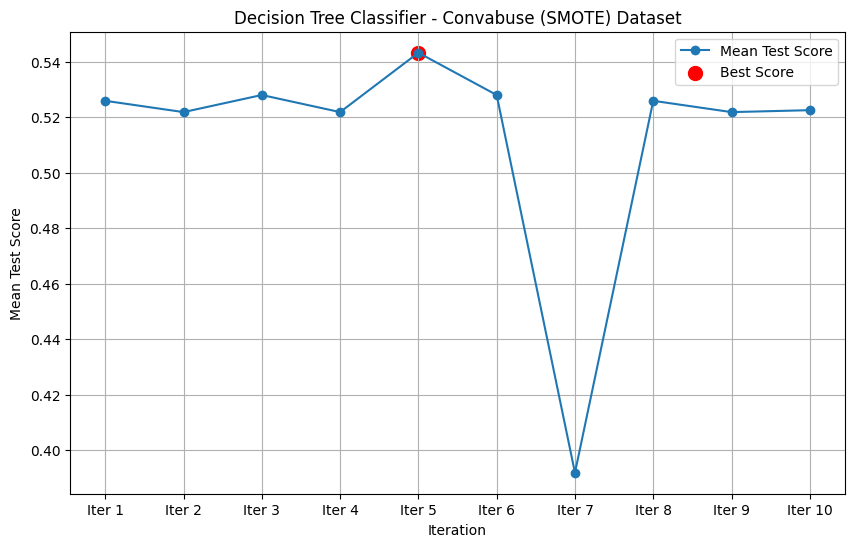

Convabuse (SMOTE) Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.5340
F1 Score: 0.5221


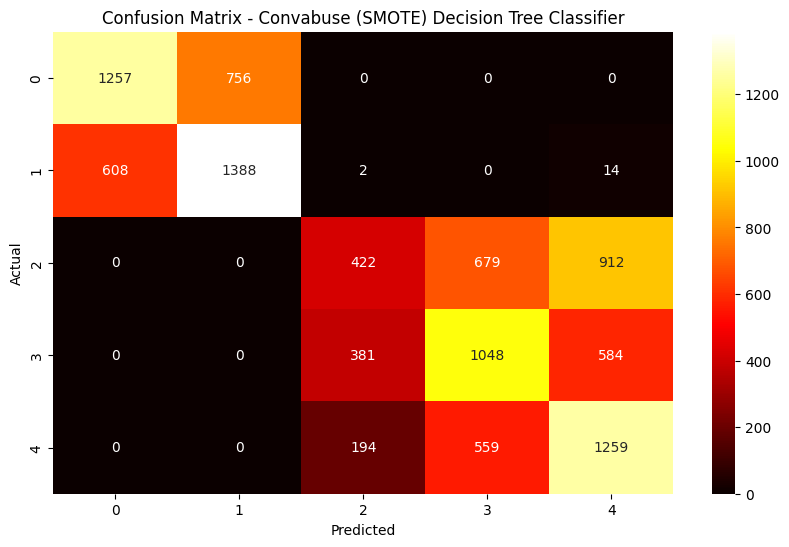

Classification Report for Convabuse (SMOTE) Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.67      0.62      0.65      2013
           1       0.65      0.69      0.67      2012
           2       0.42      0.21      0.28      2013
           3       0.46      0.52      0.49      2013
           4       0.45      0.63      0.53      2012

    accuracy                           0.53     10063
   macro avg       0.53      0.53      0.52     10063
weighted avg       0.53      0.53      0.52     10063

Unsorted Feature Importances for Convabuse (SMOTE) Decision Tree Classifier:
{'annotator_id': np.float64(0.15699284559210386), 'bot': np.float64(0.06829105161296706), 'system': np.float64(0.7747161027949291)}


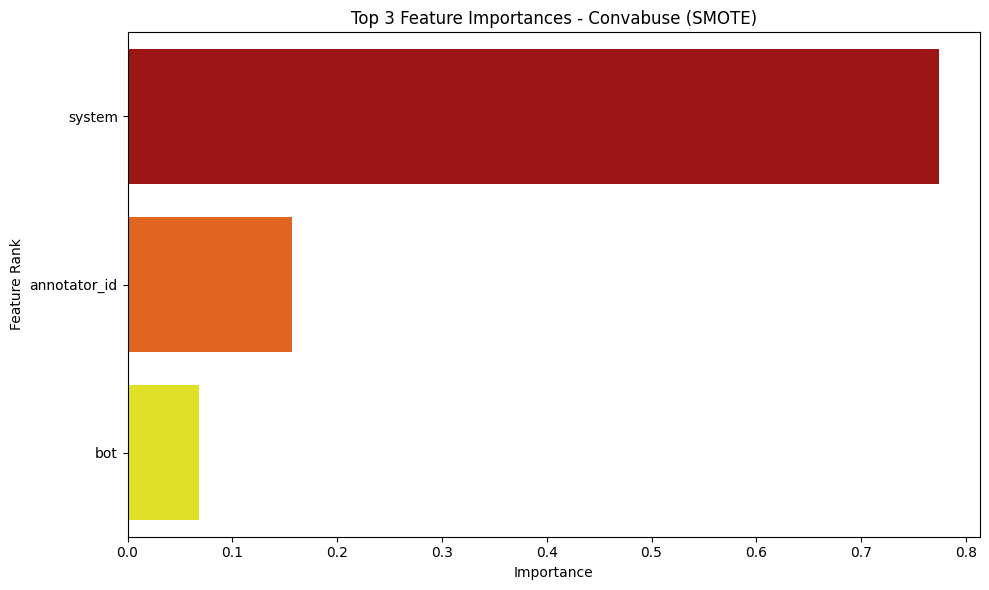

Top 3 Feature Importances for Convabuse (SMOTE) Decision Tree Classifier:
{'system': np.float64(0.7747161027949291), 'annotator_id': np.float64(0.15699284559210386), 'bot': np.float64(0.06829105161296706)}


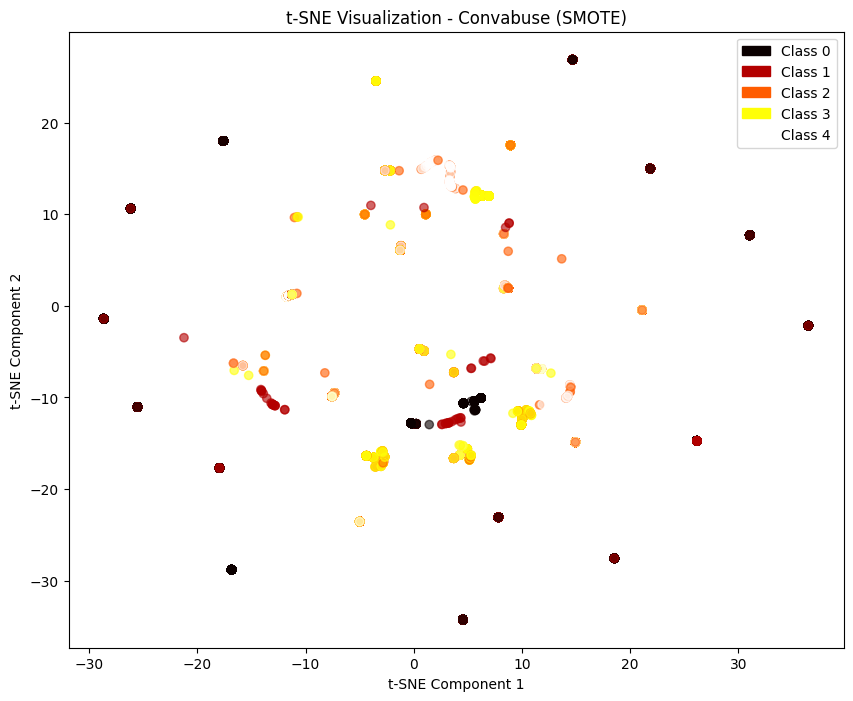

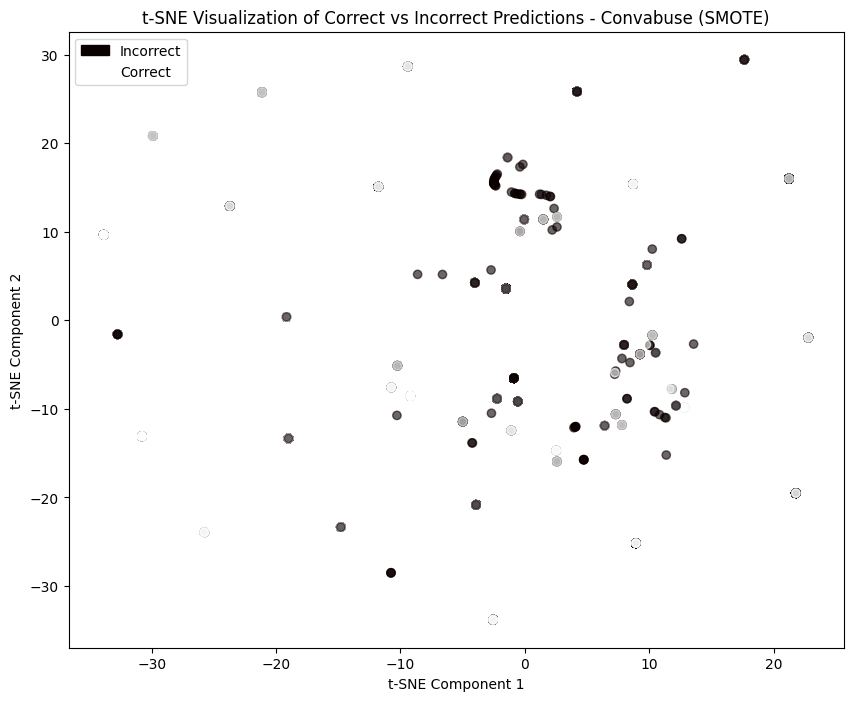

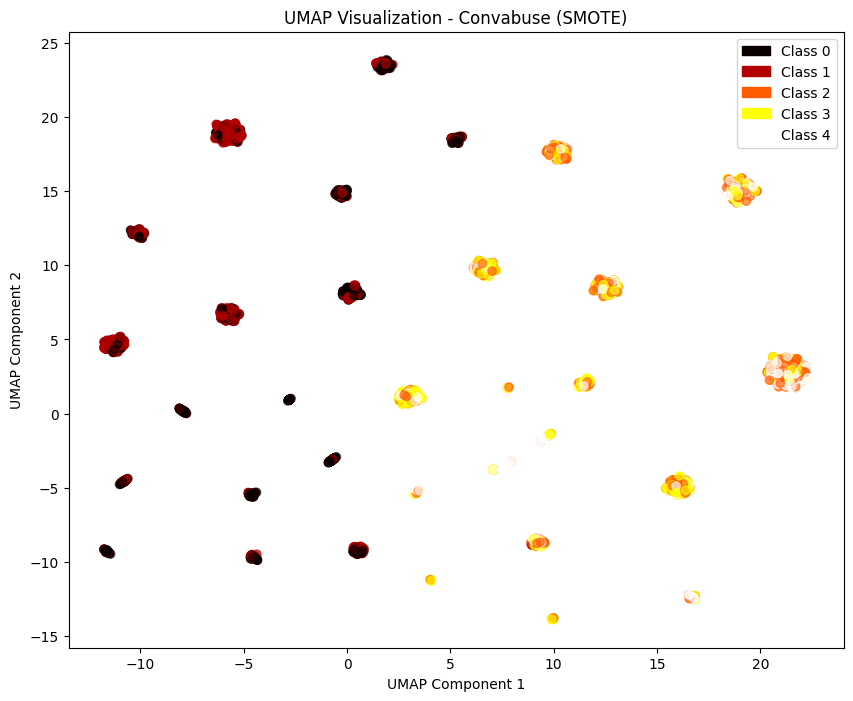

[('Decision Tree',
  'Convabuse',
  'NA',
  'NA',
  0.5340355758720063,
  0.5221166680649962,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706),
   'system': np.float64(0.7747161027949291)},
  {'system': np.float64(0.7747161027949291),
   'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706)})]

In [37]:
dt_classifier_model(convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test, "Convabuse")
dt_classification_results_list

Best parameters for Dynamically Generated Hate Speech (SMOTE) Decision Tree Classifier: {'dt_classifier__min_samples_split': 1408, 'dt_classifier__min_samples_leaf': 1056, 'dt_classifier__max_depth': 6, 'dt_classifier__criterion': 'gini'}
Best score for Dynamically Generated Hate Speech (SMOTE) Decision Tree Classifier: 0.8488107610272178
Time taken for Dynamically Generated Hate Speech (SMOTE) Decision Tree Classifier Randomized Search: 1.043447494506836


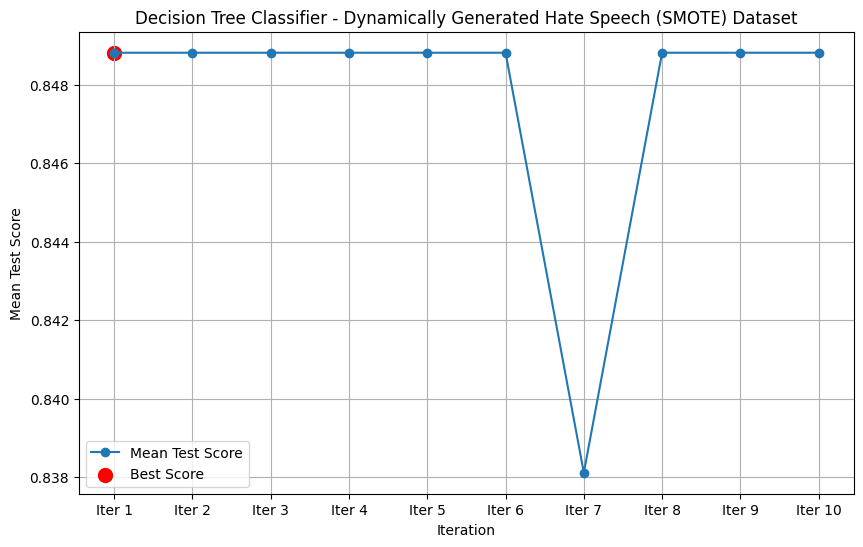

Dynamically Generated Hate Speech (SMOTE) Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1408, 'dt_classifier__min_samples_leaf': 1056, 'dt_classifier__max_depth': 6, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.8458
F1 Score: 0.8445


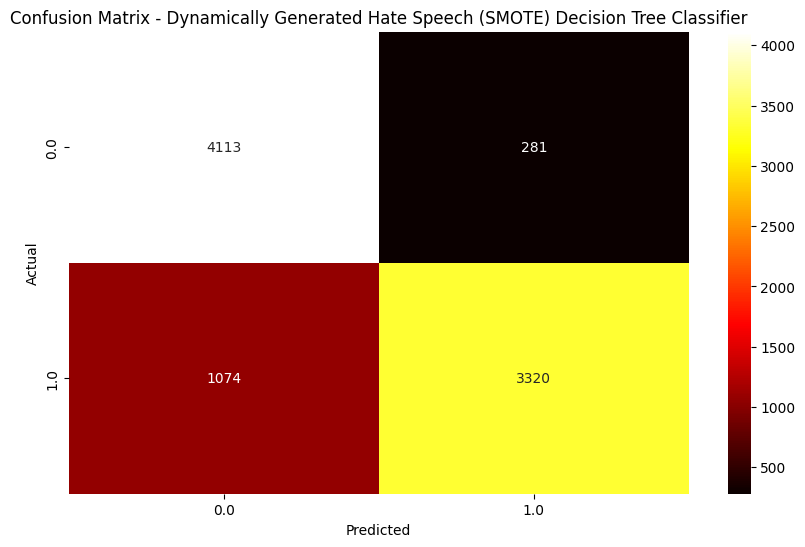

Classification Report for Dynamically Generated Hate Speech (SMOTE) Decision Tree Classifier:
              precision    recall  f1-score   support

         0.0       0.79      0.94      0.86      4394
         1.0       0.92      0.76      0.83      4394

    accuracy                           0.85      8788
   macro avg       0.86      0.85      0.84      8788
weighted avg       0.86      0.85      0.84      8788

Unsorted Feature Importances for Dynamically Generated Hate Speech (SMOTE) Decision Tree Classifier:
{'type': np.float64(0.8420953658019769), 'annotator': np.float64(0.04514313620357637), 'original': np.float64(0.1127614979944468)}


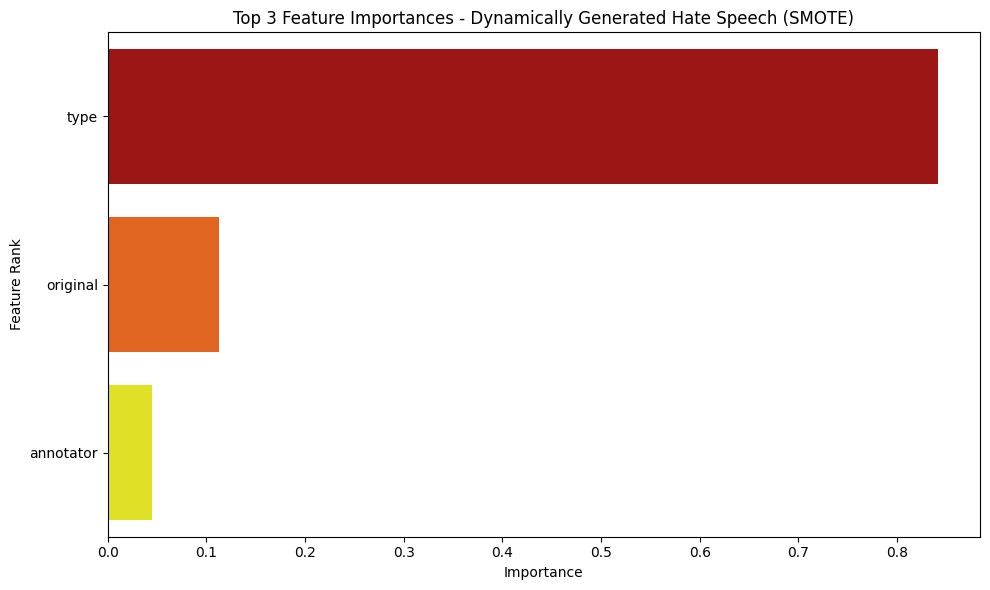

Top 3 Feature Importances for Dynamically Generated Hate Speech (SMOTE) Decision Tree Classifier:
{'type': np.float64(0.8420953658019769), 'original': np.float64(0.1127614979944468), 'annotator': np.float64(0.04514313620357637)}


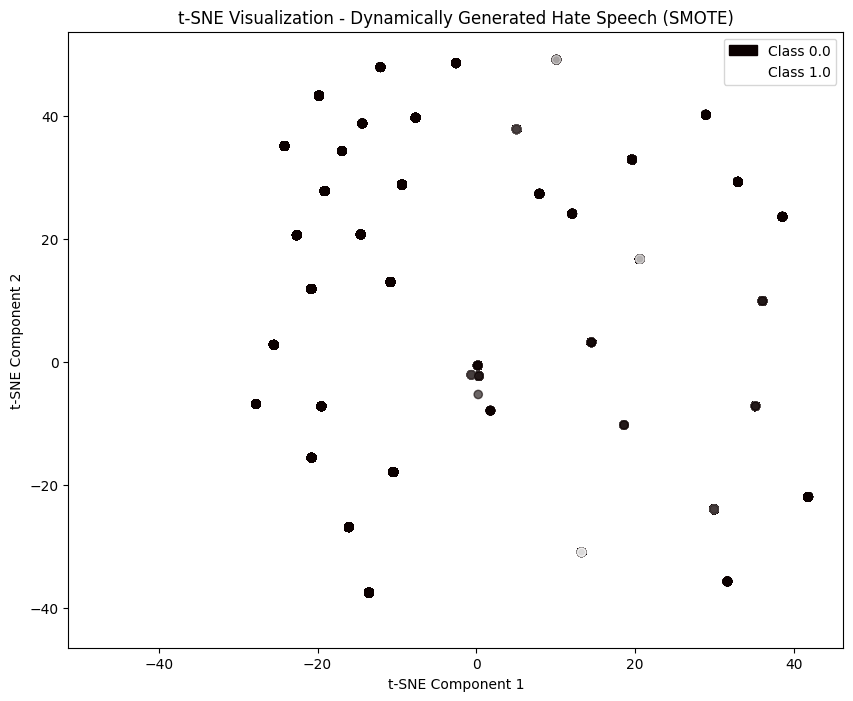

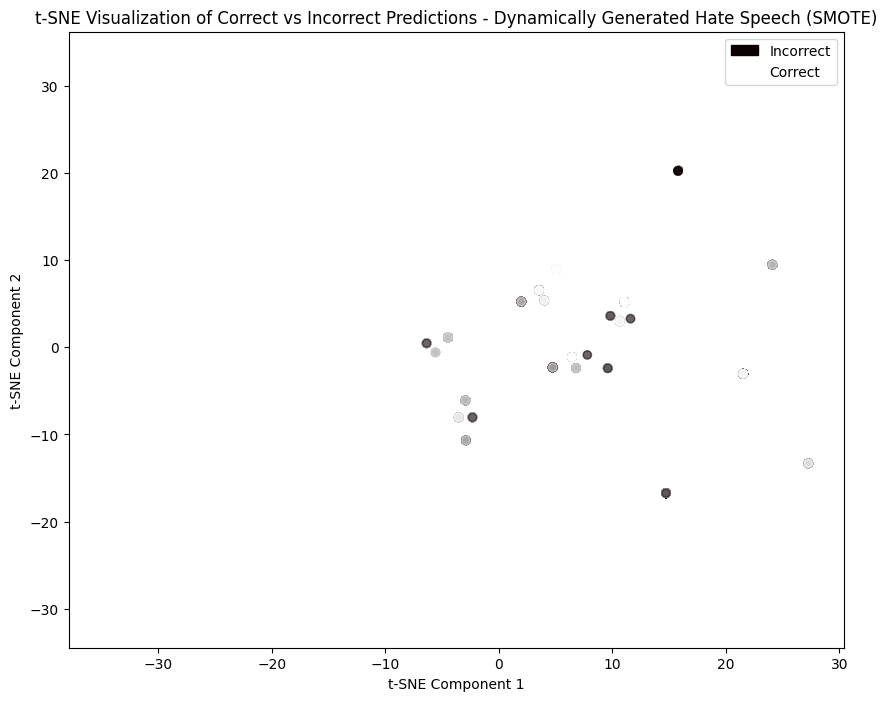

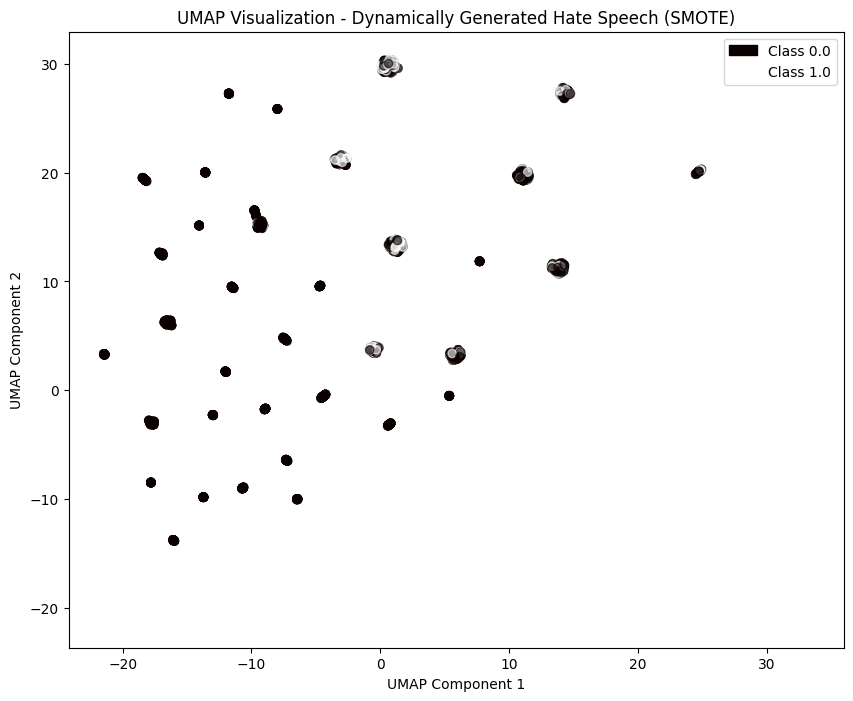

[('Decision Tree',
  'Convabuse',
  'NA',
  'NA',
  0.5340355758720063,
  0.5221166680649962,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706),
   'system': np.float64(0.7747161027949291)},
  {'system': np.float64(0.7747161027949291),
   'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706)}),
 ('Decision Tree',
  'Dynamically Generated Hate Speech',
  'NA',
  'NA',
  0.8458124715521165,
  0.8445466679904248,
  0.0,
  {'dt_classifier__min_samples_split': 1408,
   'dt_classifier__min_samples_leaf': 1056,
   'dt_classifier__max_depth': 6,
   'dt_classifier__criterion': 'gini'},
  {'type': np.float64(0.8420953658019769),
   'annotator': np.float64(0.04514313620357637),
   'original': np.float64(0.1127614979944468)},
  {'type': np.float64(0.8

In [38]:
dt_classifier_model(dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test, "Dynamically Generated Hate Speech")
dt_classification_results_list

Best parameters for Online Abusive Attacks (SMOTE) Decision Tree Classifier: {'dt_classifier__min_samples_split': 180, 'dt_classifier__min_samples_leaf': 45, 'dt_classifier__max_depth': 11, 'dt_classifier__criterion': 'entropy'}
Best score for Online Abusive Attacks (SMOTE) Decision Tree Classifier: 0.9530104523451423
Time taken for Online Abusive Attacks (SMOTE) Decision Tree Classifier Randomized Search: 0.5552911758422852


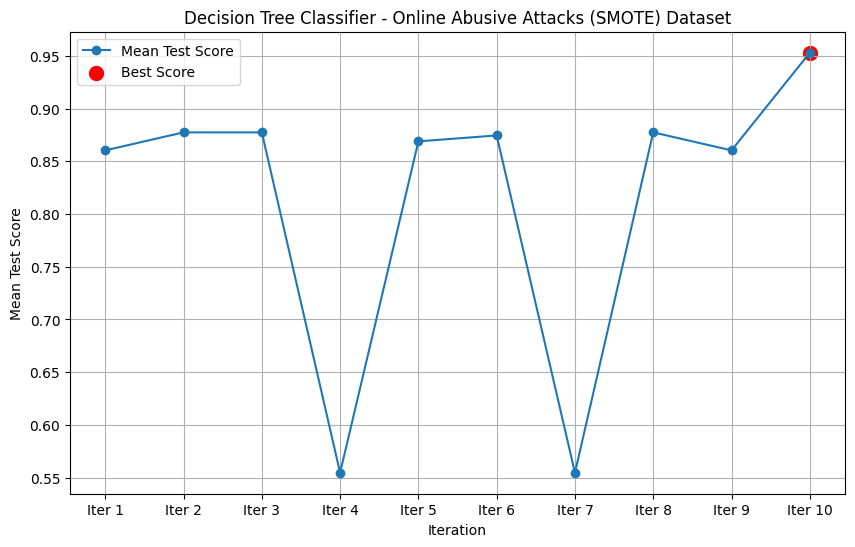

Online Abusive Attacks (SMOTE) Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 180, 'dt_classifier__min_samples_leaf': 45, 'dt_classifier__max_depth': 11, 'dt_classifier__criterion': 'entropy'}
Accuracy: 0.9550
F1 Score: 0.9551


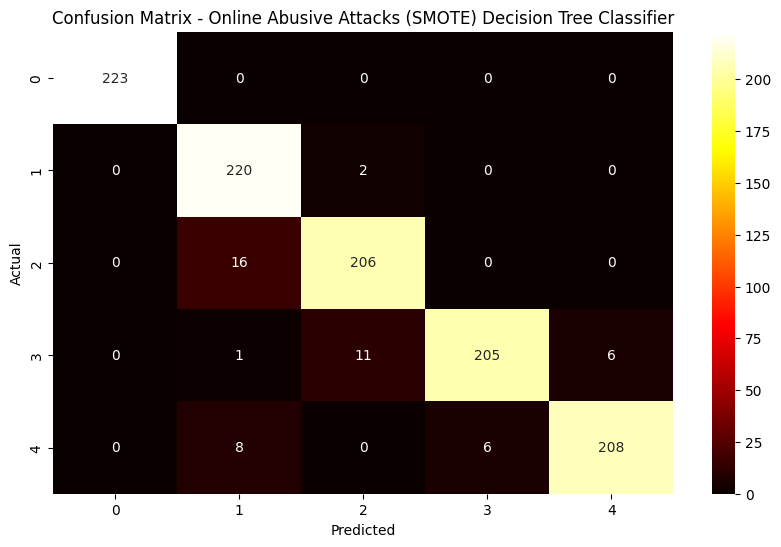

Classification Report for Online Abusive Attacks (SMOTE) Decision Tree Classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       223
           1       0.90      0.99      0.94       222
           2       0.94      0.93      0.93       222
           3       0.97      0.92      0.94       223
           4       0.97      0.94      0.95       222

    accuracy                           0.96      1112
   macro avg       0.96      0.96      0.96      1112
weighted avg       0.96      0.96      0.96      1112

Unsorted Feature Importances for Online Abusive Attacks (SMOTE) Decision Tree Classifier:
{'Toxic parent tweets': np.float64(0.7297916320703196), 'Toxic replies': np.float64(0.2702083679296804)}


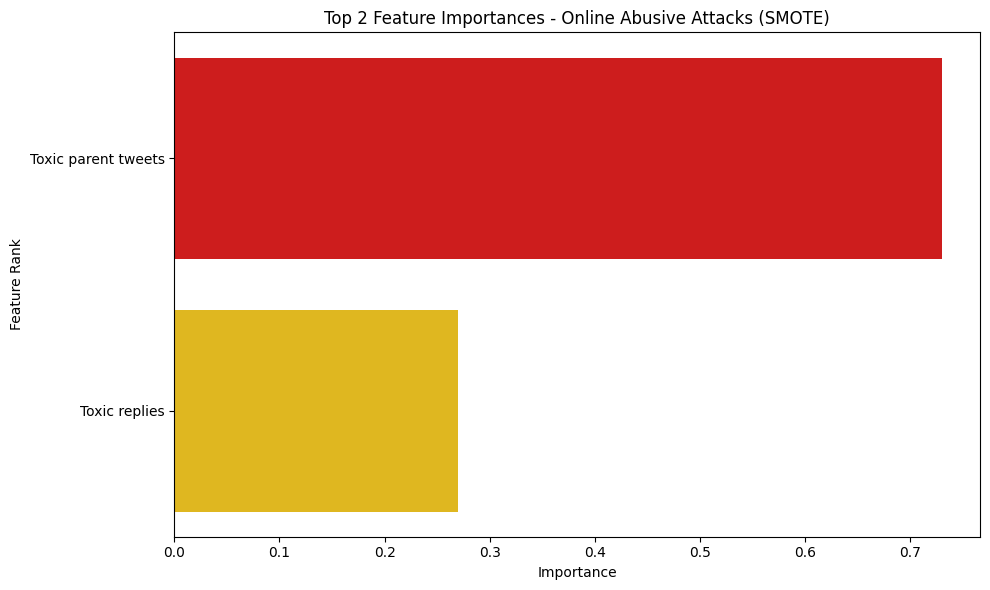

Top 2 Feature Importances for Online Abusive Attacks (SMOTE) Decision Tree Classifier:
{'Toxic parent tweets': np.float64(0.7297916320703196), 'Toxic replies': np.float64(0.2702083679296804)}


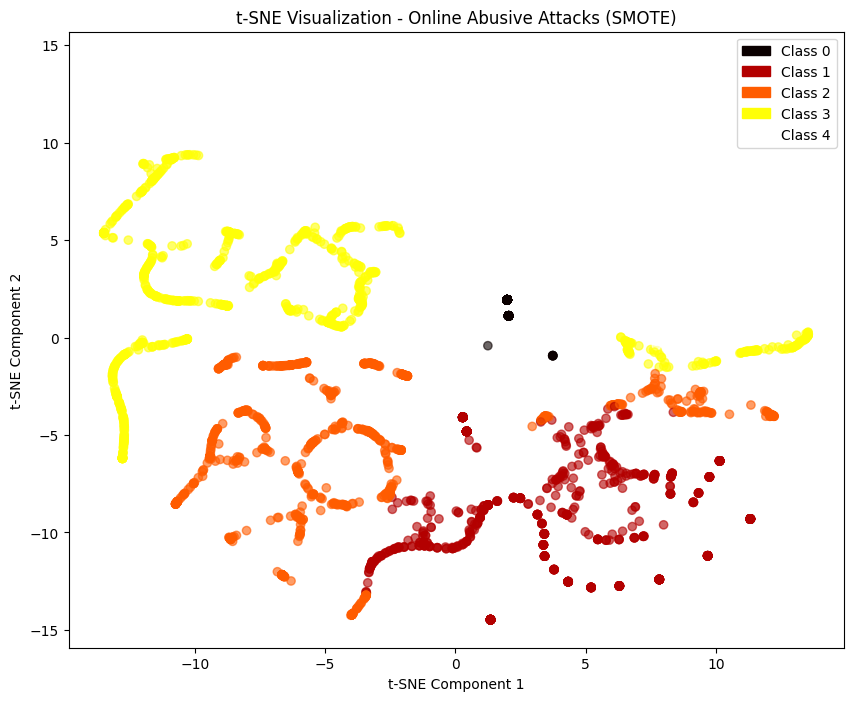

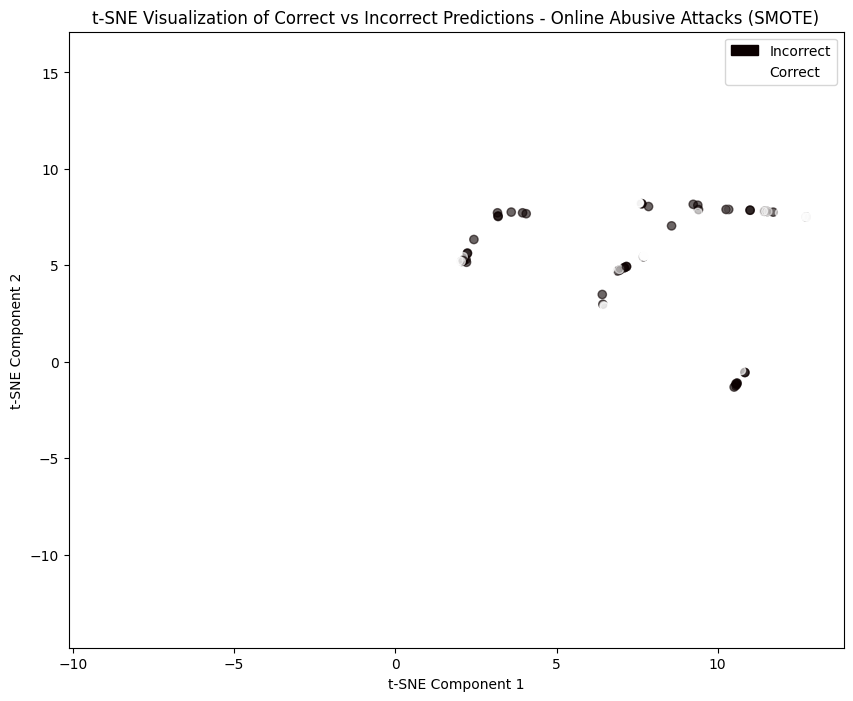

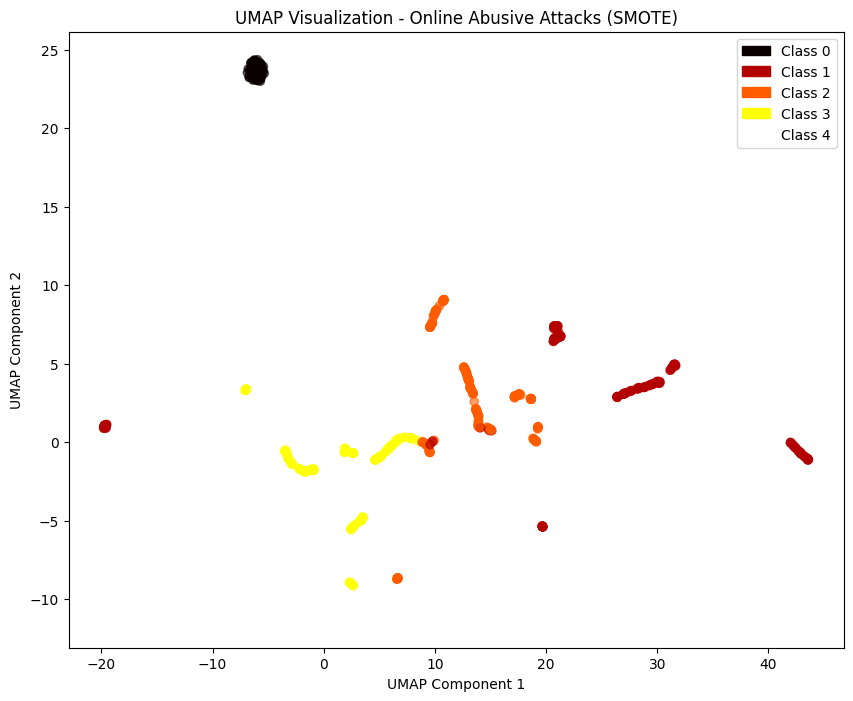

[('Decision Tree',
  'Convabuse',
  'NA',
  'NA',
  0.5340355758720063,
  0.5221166680649962,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706),
   'system': np.float64(0.7747161027949291)},
  {'system': np.float64(0.7747161027949291),
   'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706)}),
 ('Decision Tree',
  'Dynamically Generated Hate Speech',
  'NA',
  'NA',
  0.8458124715521165,
  0.8445466679904248,
  0.0,
  {'dt_classifier__min_samples_split': 1408,
   'dt_classifier__min_samples_leaf': 1056,
   'dt_classifier__max_depth': 6,
   'dt_classifier__criterion': 'gini'},
  {'type': np.float64(0.8420953658019769),
   'annotator': np.float64(0.04514313620357637),
   'original': np.float64(0.1127614979944468)},
  {'type': np.float64(0.8

In [39]:
dt_classifier_model(oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test, "Online Abusive Attacks")
dt_classification_results_list

Best parameters for US Elections 2020 Hate Speech (SMOTE) Decision Tree Classifier: {'dt_classifier__min_samples_split': 129, 'dt_classifier__min_samples_leaf': 172, 'dt_classifier__max_depth': 4, 'dt_classifier__criterion': 'gini'}
Best score for US Elections 2020 Hate Speech (SMOTE) Decision Tree Classifier: 0.682611402450994
Time taken for US Elections 2020 Hate Speech (SMOTE) Decision Tree Classifier Randomized Search: 0.36116838455200195


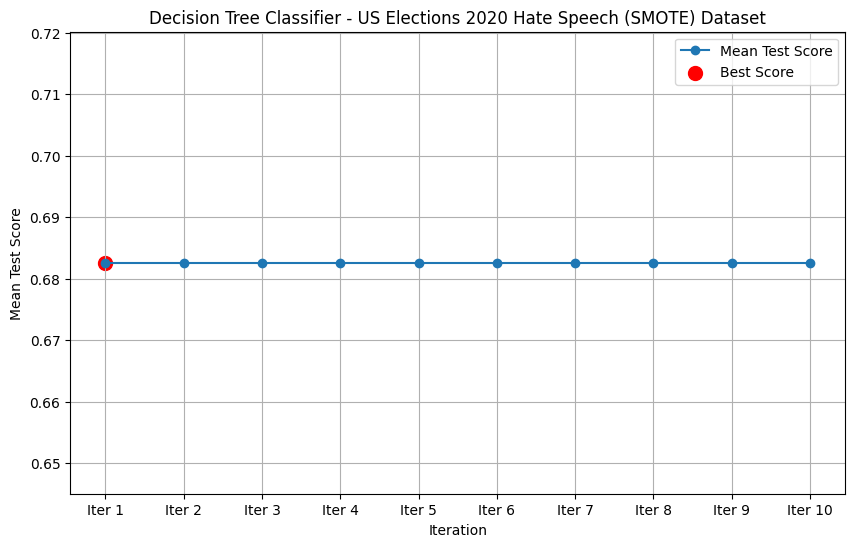

US Elections 2020 Hate Speech (SMOTE) Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 129, 'dt_classifier__min_samples_leaf': 172, 'dt_classifier__max_depth': 4, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.7045
F1 Score: 0.7035


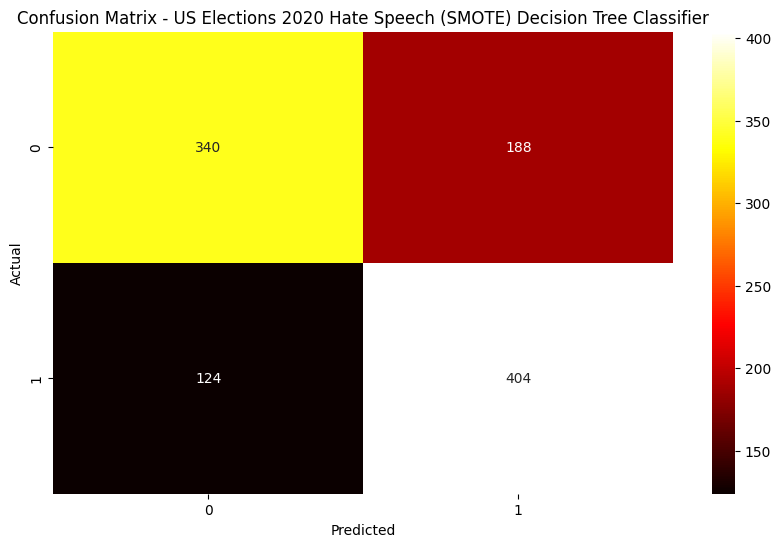

Classification Report for US Elections 2020 Hate Speech (SMOTE) Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.73      0.64      0.69       528
           1       0.68      0.77      0.72       528

    accuracy                           0.70      1056
   macro avg       0.71      0.70      0.70      1056
weighted avg       0.71      0.70      0.70      1056

Unsorted Feature Importances for US Elections 2020 Hate Speech (SMOTE) Decision Tree Classifier:
{'Trump': np.float64(0.5968140469522171), 'Biden': np.float64(0.4031859530477829)}


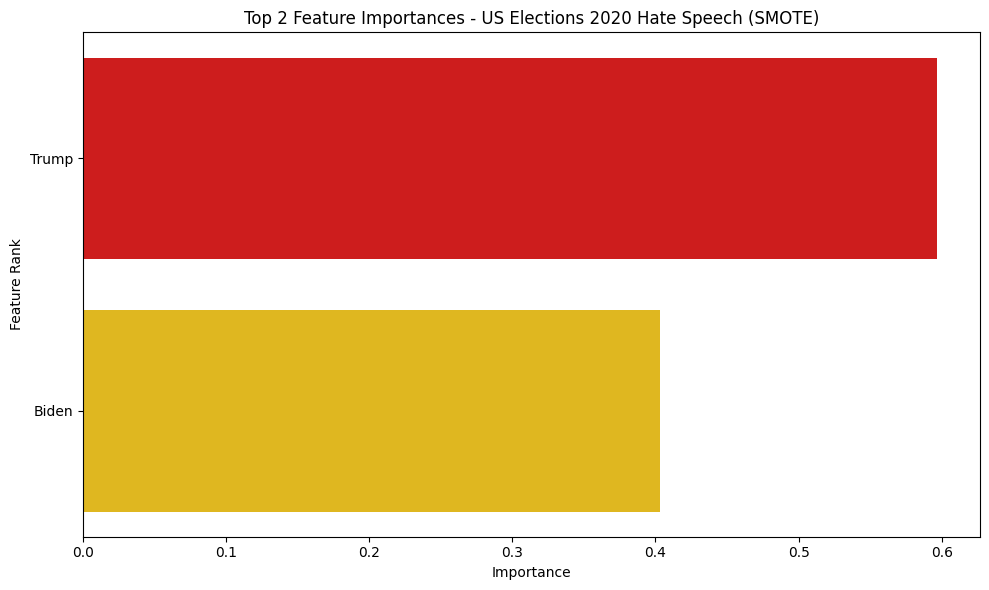

Top 2 Feature Importances for US Elections 2020 Hate Speech (SMOTE) Decision Tree Classifier:
{'Trump': np.float64(0.5968140469522171), 'Biden': np.float64(0.4031859530477829)}


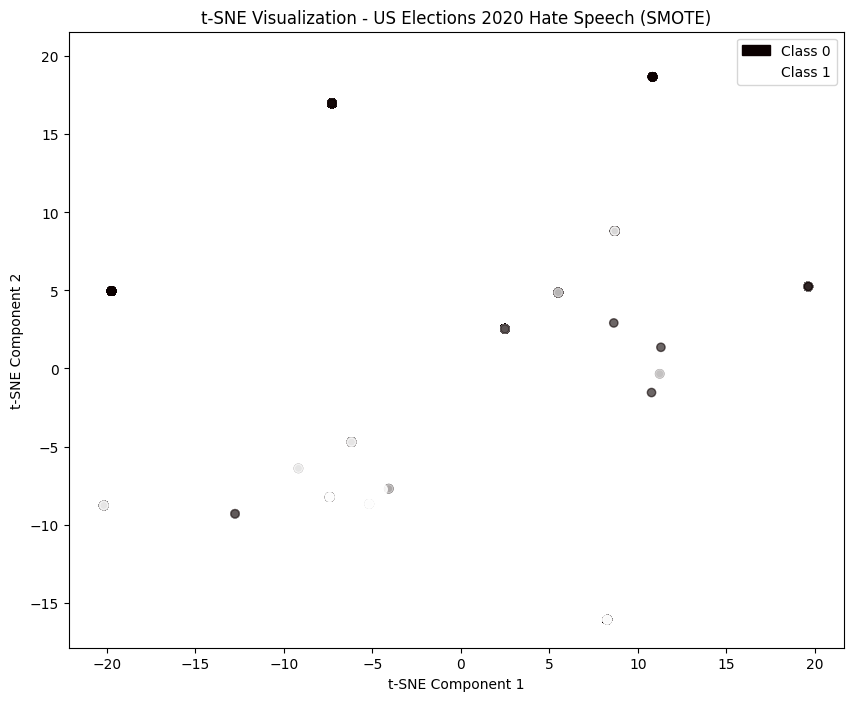

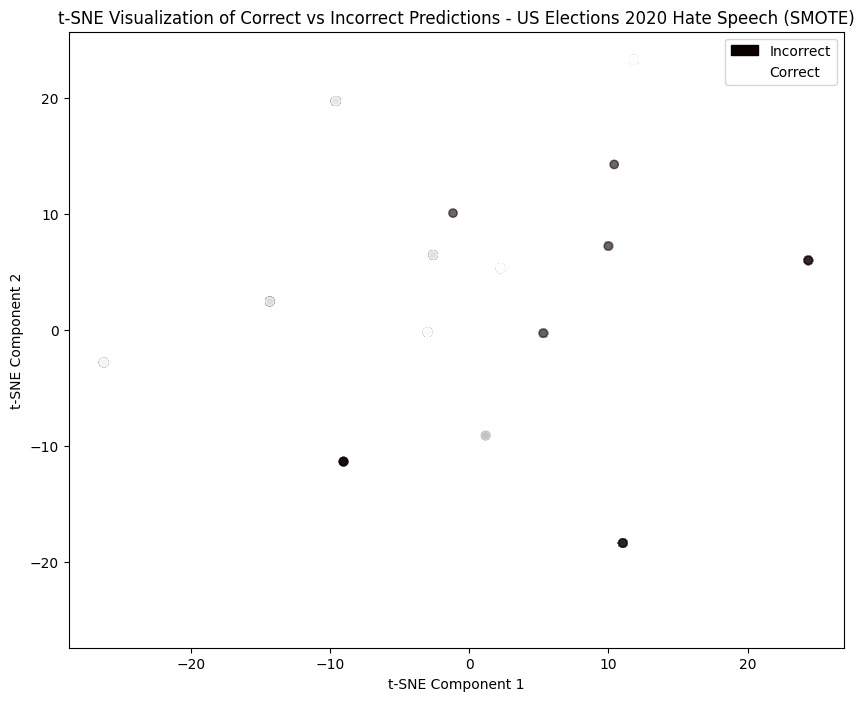

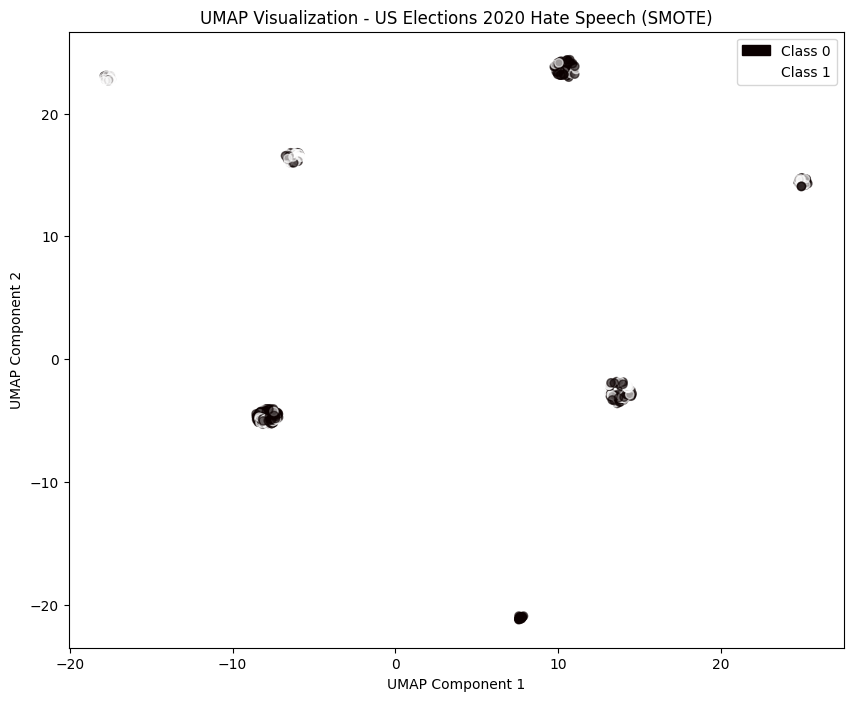

[('Decision Tree',
  'Convabuse',
  'NA',
  'NA',
  0.5340355758720063,
  0.5221166680649962,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706),
   'system': np.float64(0.7747161027949291)},
  {'system': np.float64(0.7747161027949291),
   'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706)}),
 ('Decision Tree',
  'Dynamically Generated Hate Speech',
  'NA',
  'NA',
  0.8458124715521165,
  0.8445466679904248,
  0.0,
  {'dt_classifier__min_samples_split': 1408,
   'dt_classifier__min_samples_leaf': 1056,
   'dt_classifier__max_depth': 6,
   'dt_classifier__criterion': 'gini'},
  {'type': np.float64(0.8420953658019769),
   'annotator': np.float64(0.04514313620357637),
   'original': np.float64(0.1127614979944468)},
  {'type': np.float64(0.8

In [40]:
dt_classifier_model(us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test, "US Elections 2020 Hate Speech")
dt_classification_results_list

Best parameters for MLMA Hate Speech (SMOTE) Decision Tree Classifier: {'dt_classifier__min_samples_split': 1041, 'dt_classifier__min_samples_leaf': 347, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Best score for MLMA Hate Speech (SMOTE) Decision Tree Classifier: 0.4394820562521916
Time taken for MLMA Hate Speech (SMOTE) Decision Tree Classifier Randomized Search: 1.0019373893737793


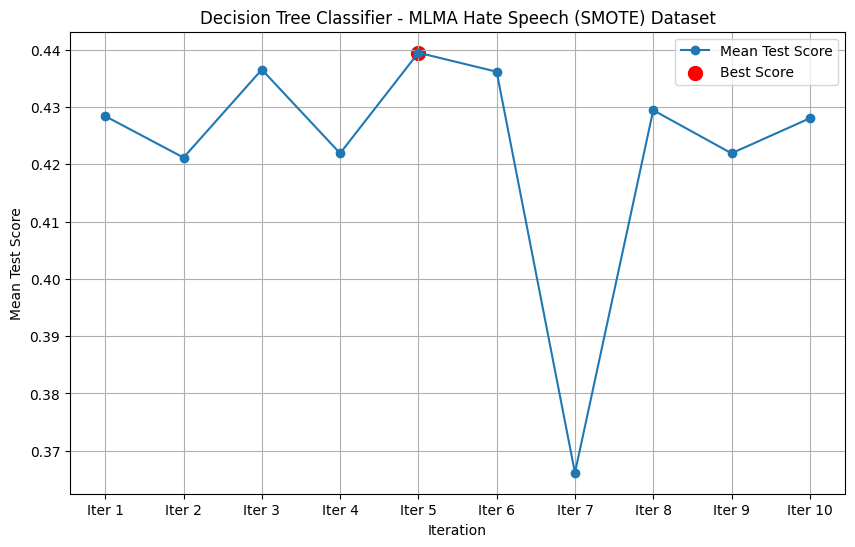

MLMA Hate Speech (SMOTE) Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1041, 'dt_classifier__min_samples_leaf': 347, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.4480
F1 Score: 0.4272


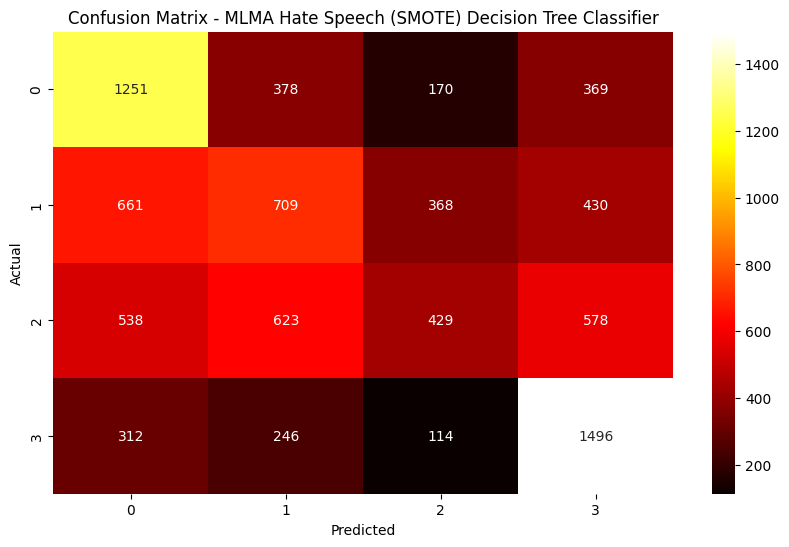

Classification Report for MLMA Hate Speech (SMOTE) Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.45      0.58      0.51      2168
           1       0.36      0.33      0.34      2168
           2       0.40      0.20      0.26      2168
           3       0.52      0.69      0.59      2168

    accuracy                           0.45      8672
   macro avg       0.43      0.45      0.43      8672
weighted avg       0.43      0.45      0.43      8672

Unsorted Feature Importances for MLMA Hate Speech (SMOTE) Decision Tree Classifier:
{'implicit': np.float64(0.4097066294573626), 'explicit': np.float64(0.0), 'annotator_sentiment': np.float64(0.47634676209276144), 'abuse_level': np.float64(0.11394660844987584)}


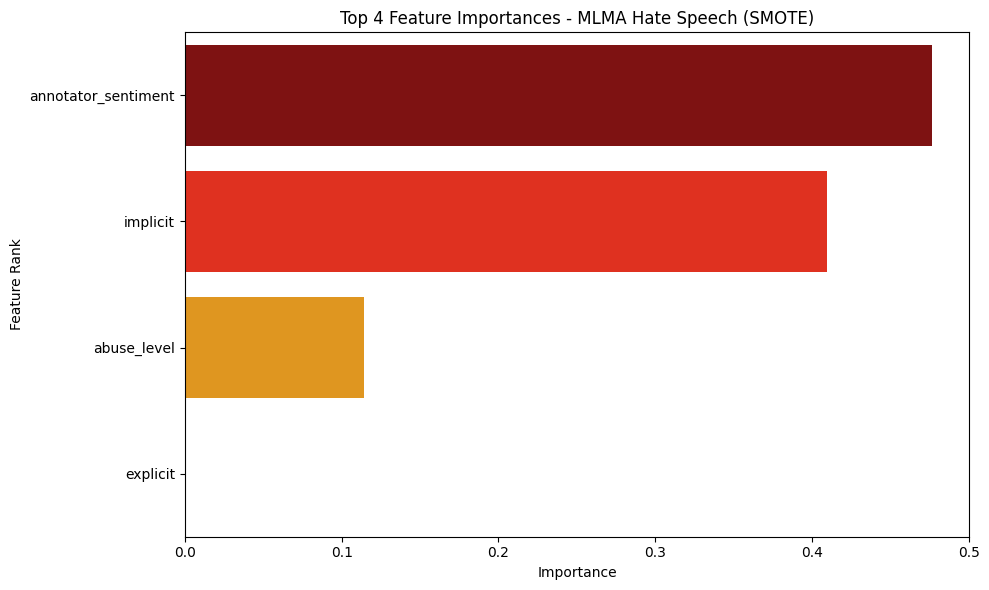

Top 4 Feature Importances for MLMA Hate Speech (SMOTE) Decision Tree Classifier:
{'annotator_sentiment': np.float64(0.47634676209276144), 'implicit': np.float64(0.4097066294573626), 'abuse_level': np.float64(0.11394660844987584), 'explicit': np.float64(0.0)}


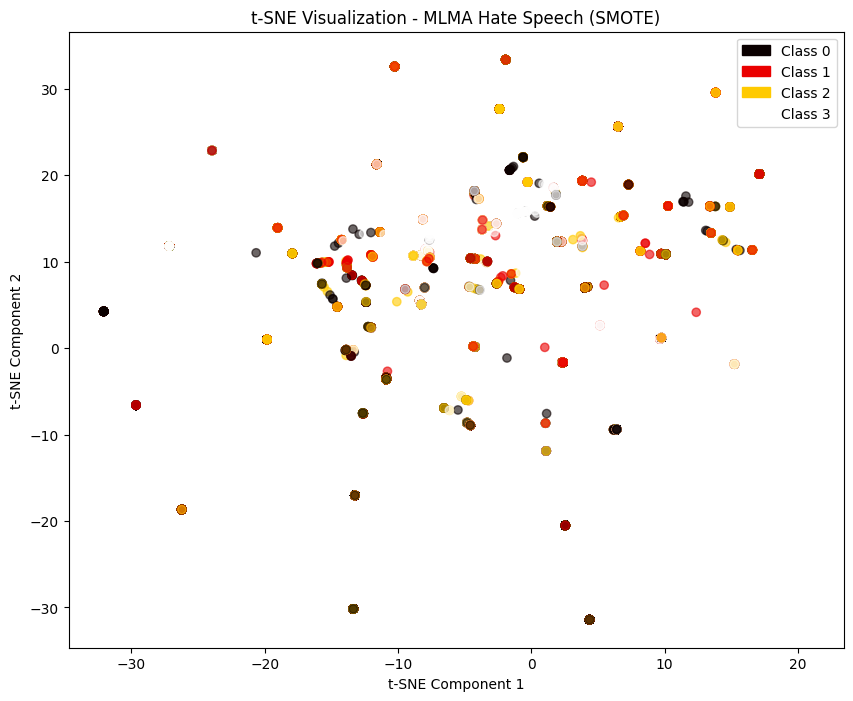

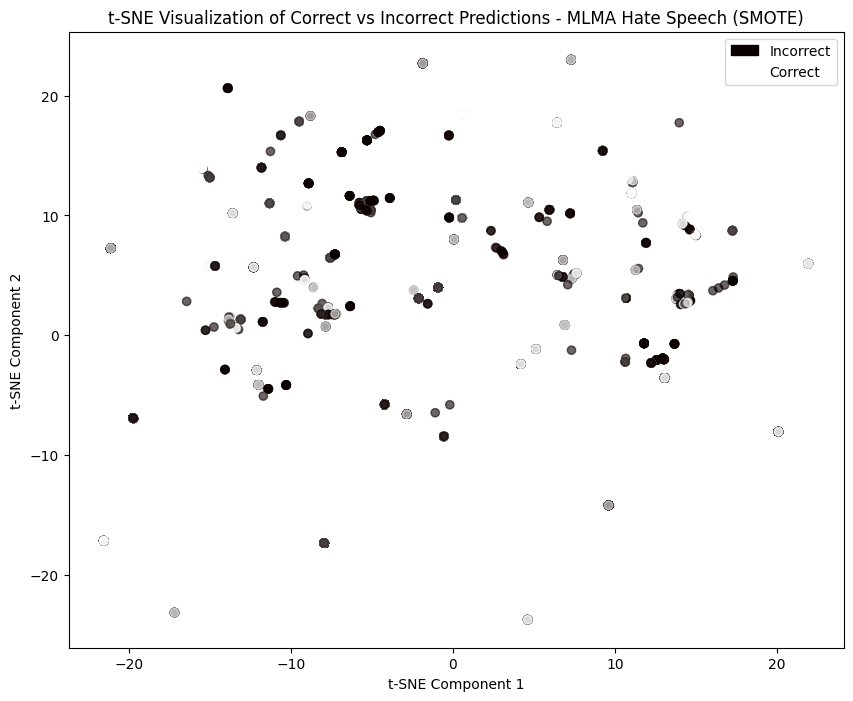

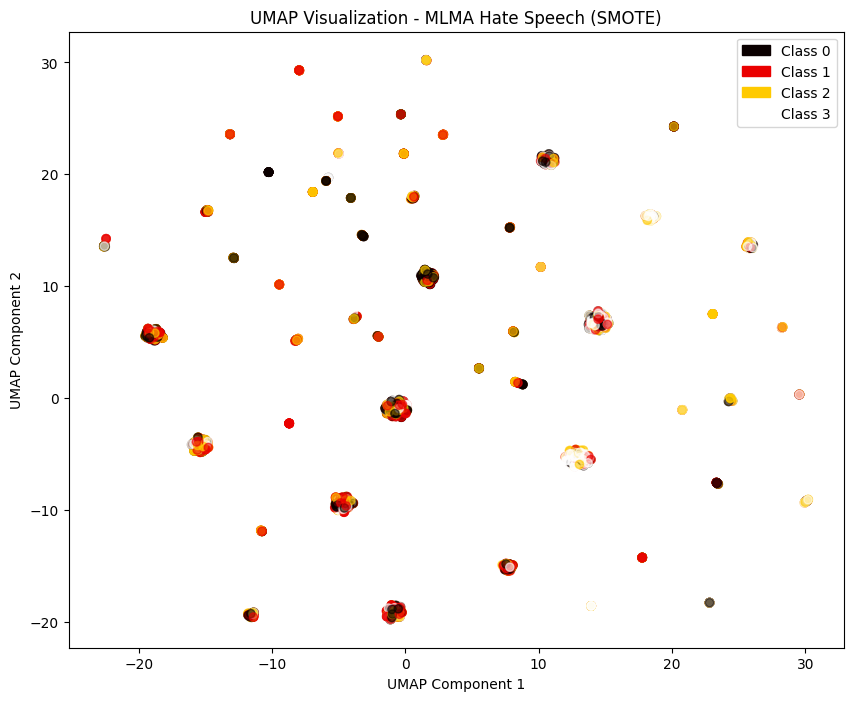

[('Decision Tree',
  'Convabuse',
  'NA',
  'NA',
  0.5340355758720063,
  0.5221166680649962,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706),
   'system': np.float64(0.7747161027949291)},
  {'system': np.float64(0.7747161027949291),
   'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706)}),
 ('Decision Tree',
  'Dynamically Generated Hate Speech',
  'NA',
  'NA',
  0.8458124715521165,
  0.8445466679904248,
  0.0,
  {'dt_classifier__min_samples_split': 1408,
   'dt_classifier__min_samples_leaf': 1056,
   'dt_classifier__max_depth': 6,
   'dt_classifier__criterion': 'gini'},
  {'type': np.float64(0.8420953658019769),
   'annotator': np.float64(0.04514313620357637),
   'original': np.float64(0.1127614979944468)},
  {'type': np.float64(0.8

In [41]:
dt_classifier_model(mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test, "MLMA Hate Speech")
dt_classification_results_list

## Support Vector Machine Conclusions

In [42]:
dt_TSNE

{'Convabuse': array([[ 22.786715 ,  -1.965726 ],
        [  9.823562 ,   6.2394814],
        [  7.3041596, -10.605133 ],
        ...,
        [ 21.785711 , -19.515669 ],
        [ 22.786715 ,  -1.965726 ],
        [ 21.235405 ,  15.994785 ]], dtype=float32),
 'Dynamically Generated Hate Speech': array([[-12.815708 ,  -7.5533633],
        [-13.99553  , -14.274523 ],
        [ 21.515562 ,  -3.0413768],
        ...,
        [-23.376856 ,  24.615349 ],
        [ 11.078819 ,   5.1849008],
        [  4.267435 , -19.835106 ]], dtype=float32),
 'Online Abusive Attacks': array([[-5.8890553, 12.456343 ],
        [-3.7746809,  5.8743563],
        [-5.5351696, -5.322101 ],
        ...,
        [-5.744826 , -7.414802 ],
        [-2.6640851,  0.4717975],
        [-5.77929  , 12.637903 ]], dtype=float32),
 'US Elections 2020 Hate Speech': array([[ 24.368433  ,   5.9994154 ],
        [  5.3251405 ,  -0.27121916],
        [ 11.036515  , -18.34745   ],
        ...,
        [  9.999615  ,   7.233804  ],


In [43]:
dt_UMAP

{'Convabuse': array([[ 21.753496 ,   1.8445843],
        [  9.212412 ,  -8.644839 ],
        [  4.0646315, -11.249704 ],
        ...,
        [  7.0181904,   9.602531 ],
        [ 21.45519  ,   2.053471 ],
        [ 16.377905 ,  -5.161981 ]], dtype=float32),
 'Dynamically Generated Hate Speech': array([[ 28.506245 ,  -3.8925307],
        [ -4.6657095,   9.59424  ],
        [ 13.90699  ,  11.119599 ],
        ...,
        [ 11.5824175, -19.215439 ],
        [ -9.452395 ,  15.093536 ],
        [ 33.00316  ,  11.827957 ]], dtype=float32),
 'Online Abusive Attacks': array([[ 3.1709998, 13.191034 ],
        [ 5.636199 ,  3.8852391],
        [-6.188427 , 23.992735 ],
        ...,
        [-6.7082434, 23.260475 ],
        [ 3.4382322, -4.8872333],
        [ 3.0926535, 13.228393 ]], dtype=float32),
 'US Elections 2020 Hate Speech': array([[ 25.020357 ,  14.407349 ],
        [ 10.169165 ,  23.4763   ],
        [ 13.963276 ,  -2.5549655],
        ...,
        [ 10.043552 ,  24.135912 ],
        

In [44]:
# import pickle
import pickle
pickle_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/'

# Pickle both dictionaries
with open(f'{pickle_path}decision-tree-TSNE-dict-SMOTE.pkl', 'wb') as f:
    pickle.dump(dt_TSNE, f)
with open(f'{pickle_path}decision-tree-UMAP-dict-SMOTE.pkl', 'wb') as f:
    pickle.dump(dt_UMAP, f)

In [45]:
dt_classification_results_list

[('Decision Tree',
  'Convabuse',
  'NA',
  'NA',
  0.5340355758720063,
  0.5221166680649962,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706),
   'system': np.float64(0.7747161027949291)},
  {'system': np.float64(0.7747161027949291),
   'annotator_id': np.float64(0.15699284559210386),
   'bot': np.float64(0.06829105161296706)}),
 ('Decision Tree',
  'Dynamically Generated Hate Speech',
  'NA',
  'NA',
  0.8458124715521165,
  0.8445466679904248,
  0.0,
  {'dt_classifier__min_samples_split': 1408,
   'dt_classifier__min_samples_leaf': 1056,
   'dt_classifier__max_depth': 6,
   'dt_classifier__criterion': 'gini'},
  {'type': np.float64(0.8420953658019769),
   'annotator': np.float64(0.04514313620357637),
   'original': np.float64(0.1127614979944468)},
  {'type': np.float64(0.8

In [46]:
# Convert the svm_results_list to a DataFrame
dt_classification_summary = pd.DataFrame(dt_classification_results_list, columns=["Model", "Dataset", "Kernel", "Regularization", "Accuracy", "F1-score", "Ratio", "Best Parameters", "Importances", "Feature Importances"])
dt_classification_summary["Balance"] = "SMOTE"
dt_classification_summary

,Model,Dataset,Kernel,Regularization,Accuracy,F1-score,Ratio,Best Parameters,Importances,Feature Importances,Balance
0,Decision Tree,Convabuse,NA,NA,0.534036,0.522117,0.0,"{'dt_classifier__min_samples_split': 1209, 'dt...","{'annotator_id': 0.15699284559210386, 'bot': 0...","{'system': 0.7747161027949291, 'annotator_id':...",SMOTE
1,Decision Tree,Dynamically Generated Hate Speech,NA,NA,0.845812,0.844547,0.0,"{'dt_classifier__min_samples_split': 1408, 'dt...","{'type': 0.8420953658019769, 'annotator': 0.04...","{'type': 0.8420953658019769, 'original': 0.112...",SMOTE
2,Decision Tree,Online Abusive Attacks,NA,NA,0.955036,0.955082,0.0,"{'dt_classifier__min_samples_split': 180, 'dt_...","{'Toxic parent tweets': 0.7297916320703196, 'T...","{'Toxic parent tweets': 0.7297916320703196, 'T...",SMOTE
3,Decision Tree,US Elections 2020 Hate Speech,NA,NA,0.704545,0.703456,0.0,"{'dt_classifier__min_samples_split': 129, 'dt_...","{'Trump': 0.5968140469522171, 'Biden': 0.40318...","{'Trump': 0.5968140469522171, 'Biden': 0.40318...",SMOTE
4,Decision Tree,MLMA Hate Speech,NA,NA,0.447994,0.427240,0.0,"{'dt_classifier__min_samples_split': 1041, 'dt...","{'implicit': 0.4097066294573626, 'explicit': 0...","{'annotator_sentiment': 0.47634676209276144, '...",SMOTE


In [47]:
dt_classification_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/model6_dt-classification-summary_SMOTE.csv", index=False)